In [34]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,DualTransformer
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [35]:
path_existence = []
data_prodromal=[]
data_swedd=[]
data_control=[]
data_PD = []
count_control = 0
count_PD = 0
count_swedd = 0
count_prodromal = 0
with open('PD1.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'E:/code/PPMI/PD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_PD=count_PD+1
            data_PD.append(row)
            
with open('control.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/PPMI/Control/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_control=count_control+1
            data_control.append(row)
    
with open('swedd.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/PPMI/SWEDD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_swedd=count_swedd+1
            data_swedd.append(row)

with open('prodromal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/PPMI/Prodromal/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_prodromal=count_prodromal+1
            data_prodromal.append(row)
print(count_PD) #44
print(count_control) #247
print(count_swedd) #106
print(count_prodromal)

125
132
72
80


In [36]:
import numpy as np
import math
import torch

replace_dict = {
    'F': '0', 'M':'1', 'Normal':'0', 'Slight':'1', 'Mild':'2', 'Moderate':'3', 'Severe':'4',
    'T1-anatomical':'1', 'Processed':'1', 'BL':'0', 'V04':'1', 'V06':'2', 'V08':'4', 'V10':'5',
    'NiFTI':'1', '': '0', 'No':'0', 'Yes':'1', 'Stage 1':'1', 'Stage 2':'2', 'Stage 3':'3', 'Stage 4':'4',
    'On':'1', 'Off':'0', 'Stage 0':'0'
}

ehr_cols = [4, 5, 82, 83]
phe_cols = list(range(12, 45)) + [78, 79, 80, 84]

def preprocess_data(data, replace_dict, target_cols):
    processed_data = []
    for row in data:
        extracted_row = [row[idx] for idx in target_cols]
        extracted_row = [replace_dict.get(item, item) for item in extracted_row]
        
        numerical_row = []
        for item in extracted_row:
            try:
                val = float(item)
                if math.isnan(val):
                    val = 0.0
            except ValueError:
                val = 0.0 
            numerical_row.append(val)
            
        processed_data.append(numerical_row)
    return np.array(processed_data)

In [37]:
pd_ehr_data = preprocess_data(data_PD, replace_dict, ehr_cols)
control_ehr_data = preprocess_data(data_control, replace_dict, ehr_cols)
swedd_ehr_data = preprocess_data(data_swedd, replace_dict, ehr_cols)
prodromal_ehr_data = preprocess_data(data_prodromal, replace_dict, ehr_cols)

pd_EHR = torch.from_numpy(pd_ehr_data).float()
control_EHR = torch.from_numpy(control_ehr_data).float()
swedd_EHR = torch.from_numpy(swedd_ehr_data).float()
prodromal_EHR = torch.from_numpy(prodromal_ehr_data).float()

linear_layer = nn.Linear(4, 1)
control_EHR = linear_layer(control_EHR)
pd_EHR = linear_layer(pd_EHR)
swedd_EHR = linear_layer(swedd_EHR)
prodromal_EHR = linear_layer(prodromal_EHR)

print('pd_EHR shape:', pd_EHR.shape)
print('control_EHR shape:', control_EHR.shape)
print('swedd_EHR shape:', swedd_EHR.shape)
print('prodromal_EHR shape:', prodromal_EHR.shape)


pd_EHR shape: torch.Size([125, 1])
control_EHR shape: torch.Size([132, 1])
swedd_EHR shape: torch.Size([72, 1])
prodromal_EHR shape: torch.Size([80, 1])


In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [39]:
# 假定你已经提前准备好了这些变量
# data_PD, data_control, data_swedd, data_prodromal 每行为csv一行
import os

pd_img_paths = [os.path.join('E:/code/PPMI/PD', row[1]) for row in data_PD if os.path.exists(os.path.join('E:/code/PPMI/PD', row[1]))]
control_img_paths = [os.path.join('E:/code/PPMI/Control', row[1]) for row in data_control if os.path.exists(os.path.join('E:/code/PPMI/Control', row[1]))]
swedd_img_paths = [os.path.join('E:/code/PPMI/SWEDD', row[1]) for row in data_swedd if os.path.exists(os.path.join('E:/code/PPMI/SWEDD', row[1]))]
prodromal_img_paths = [os.path.join('E:/code/PPMI/Prodromal', row[1]) for row in data_prodromal if os.path.exists(os.path.join('E:/code/PPMI/Prodromal', row[1]))]

print(f'PD影像数量: {len(pd_img_paths)}')            # 应为125
print(f'Control影像数量: {len(control_img_paths)}')  # 应为132
print(f'SWEDD影像数量: {len(swedd_img_paths)}')      # 应为72
print(f'Prodromal影像数量: {len(prodromal_img_paths)}')  # 应为80

batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nii = CNN_3D(num_class=1)
nii = nii.to(device)

# PD组
dataset = NiiDataset(pd_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
PD_output = torch.cat(all_outputs, dim=0)
print('PD nii shape--->', PD_output.shape)

# Control组
dataset = NiiDataset(control_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
control_output = torch.cat(all_outputs, dim=0)
print('control nii shape--->', control_output.shape)

# Prodromal组
dataset = NiiDataset(prodromal_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
prodromal_output = torch.cat(all_outputs, dim=0)
print('prodromal nii shape--->', prodromal_output.shape)

# SWEDD组
dataset = NiiDataset(swedd_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
swedd_output = torch.cat(all_outputs, dim=0)
print('swedd nii shape--->', swedd_output.shape)


PD影像数量: 125
Control影像数量: 132
SWEDD影像数量: 72
Prodromal影像数量: 80
PD nii shape---> torch.Size([125, 1])
control nii shape---> torch.Size([132, 1])
prodromal nii shape---> torch.Size([80, 1])
swedd nii shape---> torch.Size([72, 1])


In [40]:
pd_EHR = pd_EHR.cpu() 
pd_output = PD_output.cpu() 
control_EHR = control_EHR.cpu()  
control_output = control_output.cpu() 
prodromal_EHR = prodromal_EHR.cpu() 
prodromal_output = prodromal_output.cpu()  
swedd_EHR = swedd_EHR.cpu()   
swedd_output = swedd_output.cpu() 

# 拼接特征
X_pd = torch.cat([pd_EHR, pd_output], dim=1)
X_control = torch.cat([control_EHR, control_output], dim=1)
X_swedd = torch.cat([swedd_EHR, swedd_output], dim=1)
X_prodromal = torch.cat([prodromal_EHR, prodromal_output], dim=1)


# 定义类别标签
y_pd = torch.ones(len(X_pd)) * 0  # PD 类别标签为 0
y_control = torch.ones(len(X_control)) * 1  # Control 类别标签为 1
y_prodromal = torch.ones(len(X_prodromal)) * 3  # Prodomal 类别标签为 2
y_swedd = torch.ones(len(X_swedd)) * 2  # Swedd 类别标签为 3

# 拼接特征和标签
X = torch.cat([X_pd[:120], X_control, X_prodromal, X_swedd], dim=0).float()
y = torch.cat([y_pd[:120], y_control, y_prodromal, y_swedd], dim=0).float()

# 数据划分
X_train, X_test, y_train, y_test = train_test_split(
    X.detach().numpy(), y.numpy(), test_size=0.25, stratify=y.numpy(), random_state=32
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=32
)

In [41]:
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

# 创建 TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [42]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [43]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        # 获取预测概率和预测类别
        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)
    
    # 计算指标
    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

In [48]:
def evaluate(model, loader, criterion):
    model.eval()
    all_probs = []
    all_labels = []
    all_preds = []
    total_loss = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.long()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    # 计算指标
    test_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    test_f1 = f1_score(all_labels, all_preds, average='macro')
    test_recall = recall_score(all_labels, all_preds, average='macro')
    test_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, test_auc, test_f1, test_recall, test_precision

In [57]:
model = DualTransformer().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

In [58]:
train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []


for epoch in range(101):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_auc, test_f1, test_recall, test_precision = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    # 打印信息
    if epoch % 10 == 0: print(f"Epoch {epoch:03d} | "
          f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test AUC: {test_auc:.4f}")
    #print(f"Train F1: {train_f1:.4f} | Train Recall: {train_recall:.4f} | Train Precision: {train_precision:.4f}")
    #print(f"Test F1: {test_f1:.4f} | Test Recall: {test_recall:.4f} | Test Precision: {test_precision:.4f}")
    print("-" * 80)

d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 000 | Train Loss: 1.4227 | Train AUC: 0.5328 | Test Loss: 1.3772 | Test AUC: 0.4933
--------------------------------------------------------------------------------
Epoch 001 | Train Loss: 1.4608 | Train AUC: 0.5092 | Test Loss: 1.3929 | Test AUC: 0.4486
--------------------------------------------------------------------------------
Epoch 002 | Train Loss: 1.4537 | Train AUC: 0.4692 | Test Loss: 1.4039 | Test AUC: 0.4679
--------------------------------------------------------------------------------


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 003 | Train Loss: 1.4503 | Train AUC: 0.4819 | Test Loss: 1.4310 | Test AUC: 0.4816
--------------------------------------------------------------------------------
Epoch 004 | Train Loss: 1.4118 | Train AUC: 0.5352 | Test Loss: 1.4188 | Test AUC: 0.4878
--------------------------------------------------------------------------------
Epoch 005 | Train Loss: 1.3983 | Train AUC: 0.5221 | Test Loss: 1.5114 | Test AUC: 0.5023
--------------------------------------------------------------------------------


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


...

d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:17

Epoch 093 | Train Loss: 1.3894 | Train AUC: 0.5331 | Test Loss: 1.3658 | Test AUC: 0.5410
--------------------------------------------------------------------------------
Epoch 094 | Train Loss: 1.3703 | Train AUC: 0.5360 | Test Loss: 1.3398 | Test AUC: 0.5449
--------------------------------------------------------------------------------
Epoch 095 | Train Loss: 1.3638 | Train AUC: 0.5266 | Test Loss: 1.4178 | Test AUC: 0.5911
--------------------------------------------------------------------------------
Epoch 096 | Train Loss: 1.3478 | Train AUC: 0.5675 | Test Loss: 1.3243 | Test AUC: 0.5893
--------------------------------------------------------------------------------


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:17

Epoch 097 | Train Loss: 1.3651 | Train AUC: 0.5394 | Test Loss: 1.3379 | Test AUC: 0.5507
--------------------------------------------------------------------------------
Epoch 098 | Train Loss: 1.3377 | Train AUC: 0.5630 | Test Loss: 1.3488 | Test AUC: 0.5257
--------------------------------------------------------------------------------
Epoch 099 | Train Loss: 1.3851 | Train AUC: 0.5196 | Test Loss: 1.3448 | Test AUC: 0.5198
--------------------------------------------------------------------------------
Epoch 100 | Train Loss: 1.3234 | Train AUC: 0.5801 | Test Loss: 1.3467 | Test AUC: 0.5403
--------------------------------------------------------------------------------


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [59]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
# 获取预测类别
preds = np.argmax(all_probs, axis=1)
# 计算指标
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro') 
recall = recall_score(all_labels, preds, average='macro')       
f1 = f1_score(all_labels, preds, average='macro')               
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr') 
print("\n=== Final Test Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Test Metrics ===
Accuracy:  0.2376
Recall:    0.1924
F1 Score:  0.1461
Precision: 0.1233
AUC-ROC:   0.5403


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


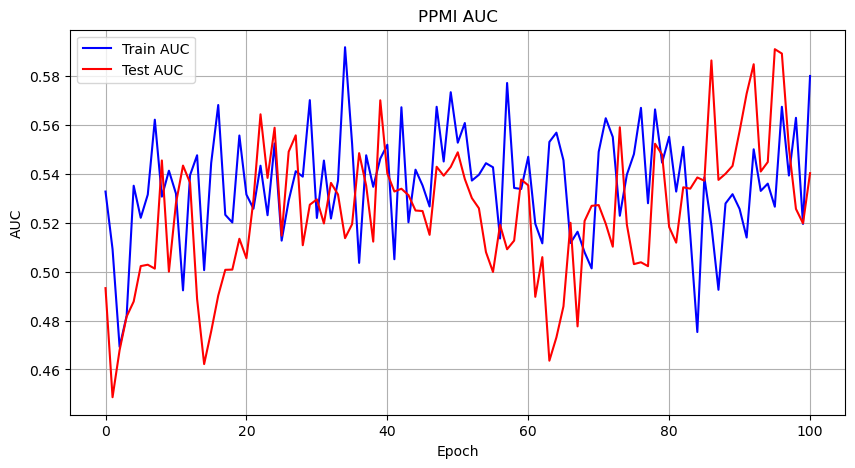

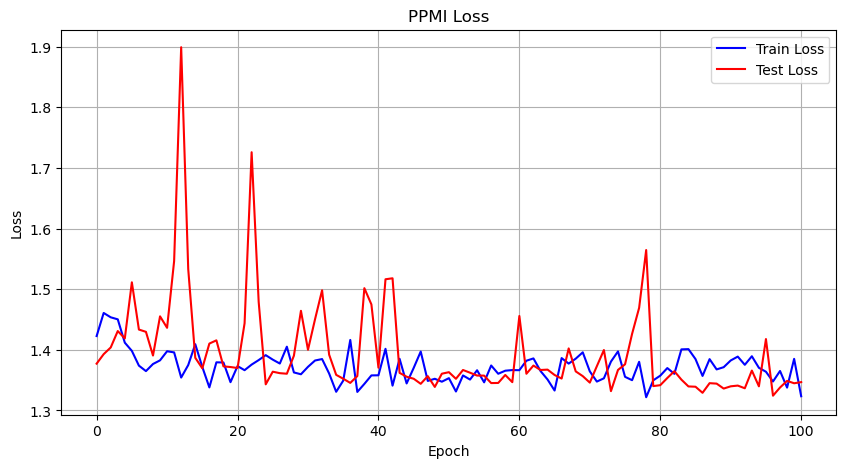

In [60]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("PPMI AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.savefig('PPMI_Baseline_Dual_plot.png', dpi=300)
plt.close()

plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("PPMI Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig('PPMI_Baseline_Dual_plot.png', dpi=300)
plt.close()